<a href="https://colab.research.google.com/github/eleojosunday2002-ai/Credit-Card-Churn-Analysis-and-Predictor/blob/git-checkout-b-data-foundation-Aishat1602/Group5_Data_foundation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q kagglehub
import kagglehub
import pandas as pd
import numpy as np
import os
import sqlite3
import matplotlib.pyplot as plt
import seaborn
path = kagglehub.dataset_download("sakshigoyal7/credit-card-customers")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'credit-card-customers' dataset.
Path to dataset files: /kaggle/input/credit-card-customers


In [ ]:
import os

print(os.listdir(path))

['BankChurners.csv']


In [ ]:
import pandas as pd

df = pd.read_csv(os.path.join(path, "BankChurners.csv"))

df.head()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.99991
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.99994
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.99998
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0.000134,0.99987
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0.000022,0.99998


In [ ]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 10127
Number of columns: 23


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 23 columns):
 #   Column                                                                                                                              Non-Null Count  Dtype  
---  ------                                                                                                                              --------------  -----  
 0   CLIENTNUM                                                                                                                           10127 non-null  int64  
 1   Attrition_Flag                                                                                                                      10127 non-null  object 
 2   Customer_Age                                                                                                                        10127 non-null  int64  
 3   Gender                                                                           

In [ ]:

missing = df.isnull().sum()

missing[missing > 0]

,0


In [ ]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_percentage[missing_percentage > 0]

,0


## Missing Values

Missing values were checked using `isnull().sum()`. Columns with missing values were identified so that appropriate cleaning decisions could be made before analysis

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df[df.duplicated()]

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2


No duplicate records were found, so no duplicate-removal operation was necessary

In [ ]:
df['Attrition_Flag'].value_counts()

,count
Attrition_Flag,
Existing Customer,8500
Attrited Customer,1627


In [ ]:
df['Attrition_Flag'].value_counts(normalize=True) * 100

,proportion
Attrition_Flag,
Existing Customer,83.934038
Attrited Customer,16.065962


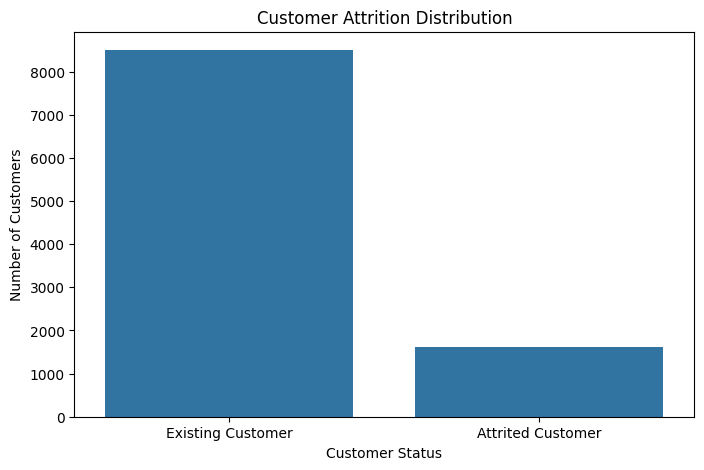

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

sns.countplot(data=df, x='Attrition_Flag')

plt.title('Customer Attrition Distribution')
plt.xlabel('Customer Status')
plt.ylabel('Number of Customers')

plt.show()

### Target Distribution

The target variable, Attrition _Flag,indicates whether a customer remained with the bank or became an attrited customer.

The dataset contains substantially more existing customers than attrited customers. This indicates that the target variable is imbalanced, with attrited customers representing a smaller proportion of the observations.

This imbalance should be considered when interpreting the analysis and any future predictive modelling.

In [ ]:

import sqlite3

conn = sqlite3.connect("credit_card_customers.db")

print("SQLite database connected successfully!")

SQLite database connected successfully!


In [ ]:
df.to_sql(
    "customers",
    conn,
    if_exists="replace",
    index=False
)

10127

Loading the Dataset into SQLite

The "to_sql()" function was used to transfer the Pandas DataFrame into the SQLite database. The DataFrame was stored as a table named "customers".

The "if_exists='replace'" parameter ensures that an existing table with the same name is replaced with the current DataFrame, while "index=False" prevents the Pandas index from being stored as an additional column.

This allows SQL queries to be performed directly on the customer dataset using the SQLite database connection.

In [ ]:

pd.read_sql_query(
    "SELECT * FROM customers LIMIT 5",
    conn
)

## This is to check that the above code is worked.

In [ ]:

query1 = """
SELECT
    Income_Category,
    COUNT(*) AS Attrited_Customers
FROM customers
WHERE Attrition_Flag = 'Attrited Customer'
GROUP BY Income_Category
ORDER BY Attrited_Customers DESC;
"""

result1 = pd.read_sql_query(query1, conn)

result1

,Income_Category,Attrited_Customers
0,Less than $40K,612
1,$40K - $60K,271
2,$80K - $120K,242
3,$60K - $80K,189
4,Unknown,187
5,$120K +,126


 Query 1: Attrited Customers by Income Category
This query identifies the number of attrited customers in each income category. The result can help the bank understand whether customer attrition is concentrated within particular income groups and may support more targeted customer-retention analysis.

In [ ]:
query2 = """
SELECT
    Card_Category,
    COUNT(*) AS Attrited_Customers
FROM customers
WHERE Attrition_Flag = 'Attrited Customer'
GROUP BY Card_Category
ORDER BY Attrited_Customers DESC;
"""

result2 = pd.read_sql_query(query2, conn)

result2

,Card_Category,Attrited_Customers
0,Blue,1519
1,Silver,82
2,Gold,21
3,Platinum,5


Query 2: Attrited Customers by Card Category

This query compares the number of attrited customers across different card categories. It provides insight into whether customer attrition varies according to the type of credit card held by customers.

In [ ]:

query3 = """
SELECT
    Months_Inactive_12_mon,
    COUNT(*) AS Attrited_Customers
FROM customers
WHERE Attrition_Flag = 'Attrited Customer'
GROUP BY Months_Inactive_12_mon
ORDER BY Months_Inactive_12_mon;
"""

result3 = pd.read_sql_query(query3, conn)

result3

,Months_Inactive_12_mon,Attrited_Customers
0,0,15
1,1,100
2,2,505
3,3,826
4,4,130
5,5,32
6,6,19


 Query 3: Customer Attrition by Inactive Months

This query examines the number of attrited customers according to their number of inactive months during the previous 12 months. The analysis can help identify whether customer inactivity is associated with higher levels of attrition.

In [ ]:
df.describe()

,CLIENTNUM,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
count,1.012700e+04,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000
mean,7.391776e+08,46.325960,2.346203,35.928409,3.812580,2.341167,2.455317,8631.953698,1162.814061,7469.139637,0.759941,4404.086304,64.858695,0.712222,0.274894,0.159997,0.840003
std,3.690378e+07,8.016814,1.298908,7.986416,1.554408,1.010622,1.106225,9088.776650,814.987335,9090.685324,0.219207,3397.129254,23.472570,0.238086,0.275691,0.365301,0.365301
min,7.080821e+08,26.000000,0.000000,13.000000,1.000000,0.000000,0.000000,1438.300000,0.000000,3.000000,0.000000,510.000000,10.000000,0.000000,0.000000,0.000008,0.000420
25%,7.130368e+08,41.000000,1.000000,31.000000,3.000000,2.000000,2.000000,2555.000000,359.000000,1324.500000,0.631000,2155.500000,45.000000,0.582000,0.023000,0.000099,0.999660
50%,7.179264e+08,46.000000,2.000000,36.000000,4.000000,2.000000,2.000000,4549.000000,1276.000000,3474.000000,0.736000,3899.000000,67.000000,0.702000,0.176000,0.000181,0.999820
75%,7.731435e+08,52.000000,3.000000,40.000000,5.000000,3.000000,3.000000,11067.500000,1784.000000,9859.000000,0.859000,4741.000000,81.000000,0.818000,0.503000,0.000337,0.999900
max,8.283431e+08,73.000000,5.000000,56.000000,6.000000,6.000000,6.000000,34516.000000,2517.000000,34516.000000,3.397000,18484.000000,139.000000,3.714000,0.999000,0.999580,0.999990


Exploratory Data Analysis (EDA)

Descriptive Statistics

Descriptive statistics were used to summarize the numerical variables in the dataset. The analysis examined variables such as customer age, credit limit, total transaction amount, and total transaction count.

The "describe()" function provides key statistical measures including the number of observations, mean, standard deviation, minimum, maximum, and quartile values. These statistics help to understand the distribution and general characteristics of the customers and their credit-card usage.

The selected variables were examined individually to gain a focused understanding of important customer and transaction-related characteristics. The complete dataset was also summarized to provide an overall statistical overview of the numerical variables.

These descriptive statistics will serve as a basis for identifying patterns, unusual values, and potential data-quality issues that may require further investigation during the exploratory data analysis and data-cleaning stages.

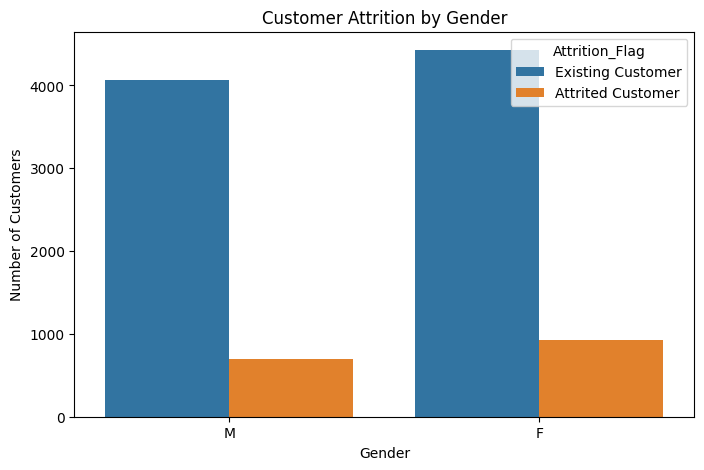

In [ ]:

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='Gender',
    hue='Attrition_Flag'
)

plt.title('Customer Attrition by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Customers')

plt.show()


EDA -Attrition by gender

 comparing the number of existing versus attrited customers across gender categories.

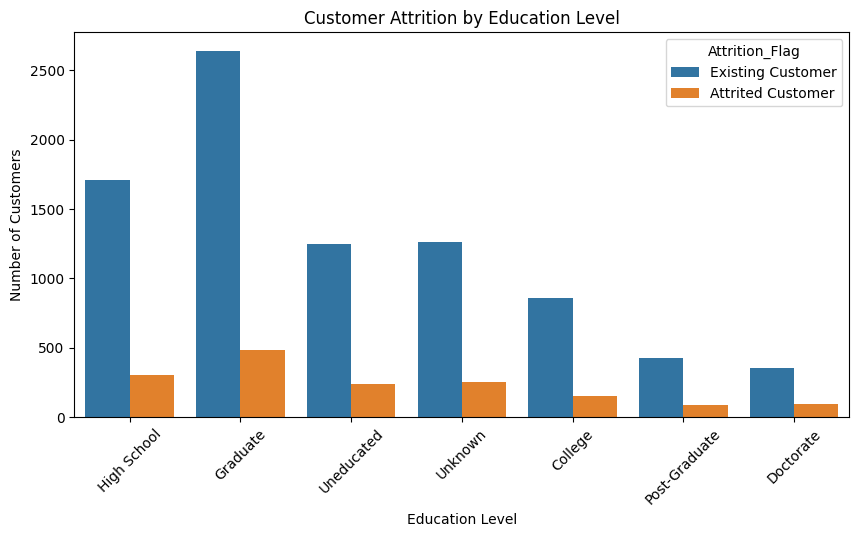

In [ ]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x='Education_Level',
    hue='Attrition_Flag'
)

plt.title('Customer Attrition by Education Level')
plt.xlabel('Education Level')
plt.ylabel('Number of Customers')

plt.xticks(rotation=45)

plt.show()

EDA -Education

 comparing the number of existing versus attrited customers across education level.

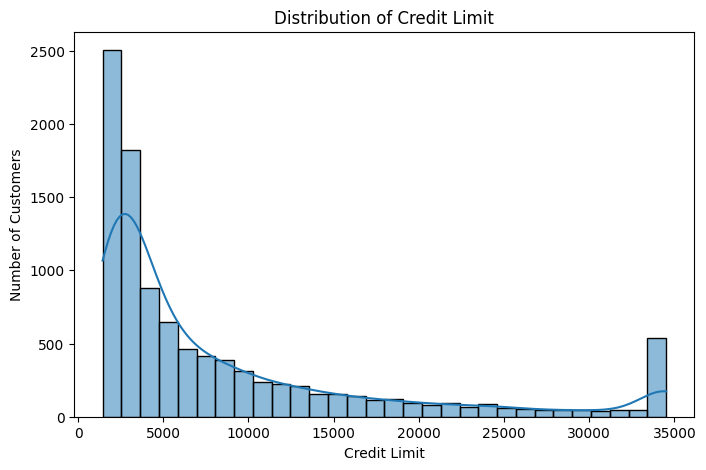

In [ ]:

plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x='Credit_Limit',
    bins=30,
    kde=True
)

plt.title('Distribution of Credit Limit')
plt.xlabel('Credit Limit')
plt.ylabel('Number of Customers')

plt.show()

EDA -Credit limit

comparing the number of existing versus attrited customers across Credit limit.

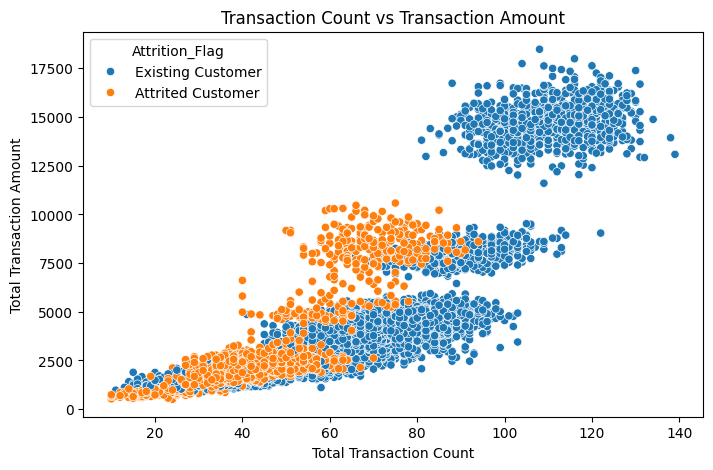

In [ ]:

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x='Total_Trans_Ct',
    y='Total_Trans_Amt',
    hue='Attrition_Flag'
)

plt.title('Transaction Count vs Transaction Amount')
plt.xlabel('Total Transaction Count')
plt.ylabel('Total Transaction Amount')

plt.show()

EDA - Transaction count vs Transaction Amount

looking for whether customers with different transaction behaviours show different attrition patterns.

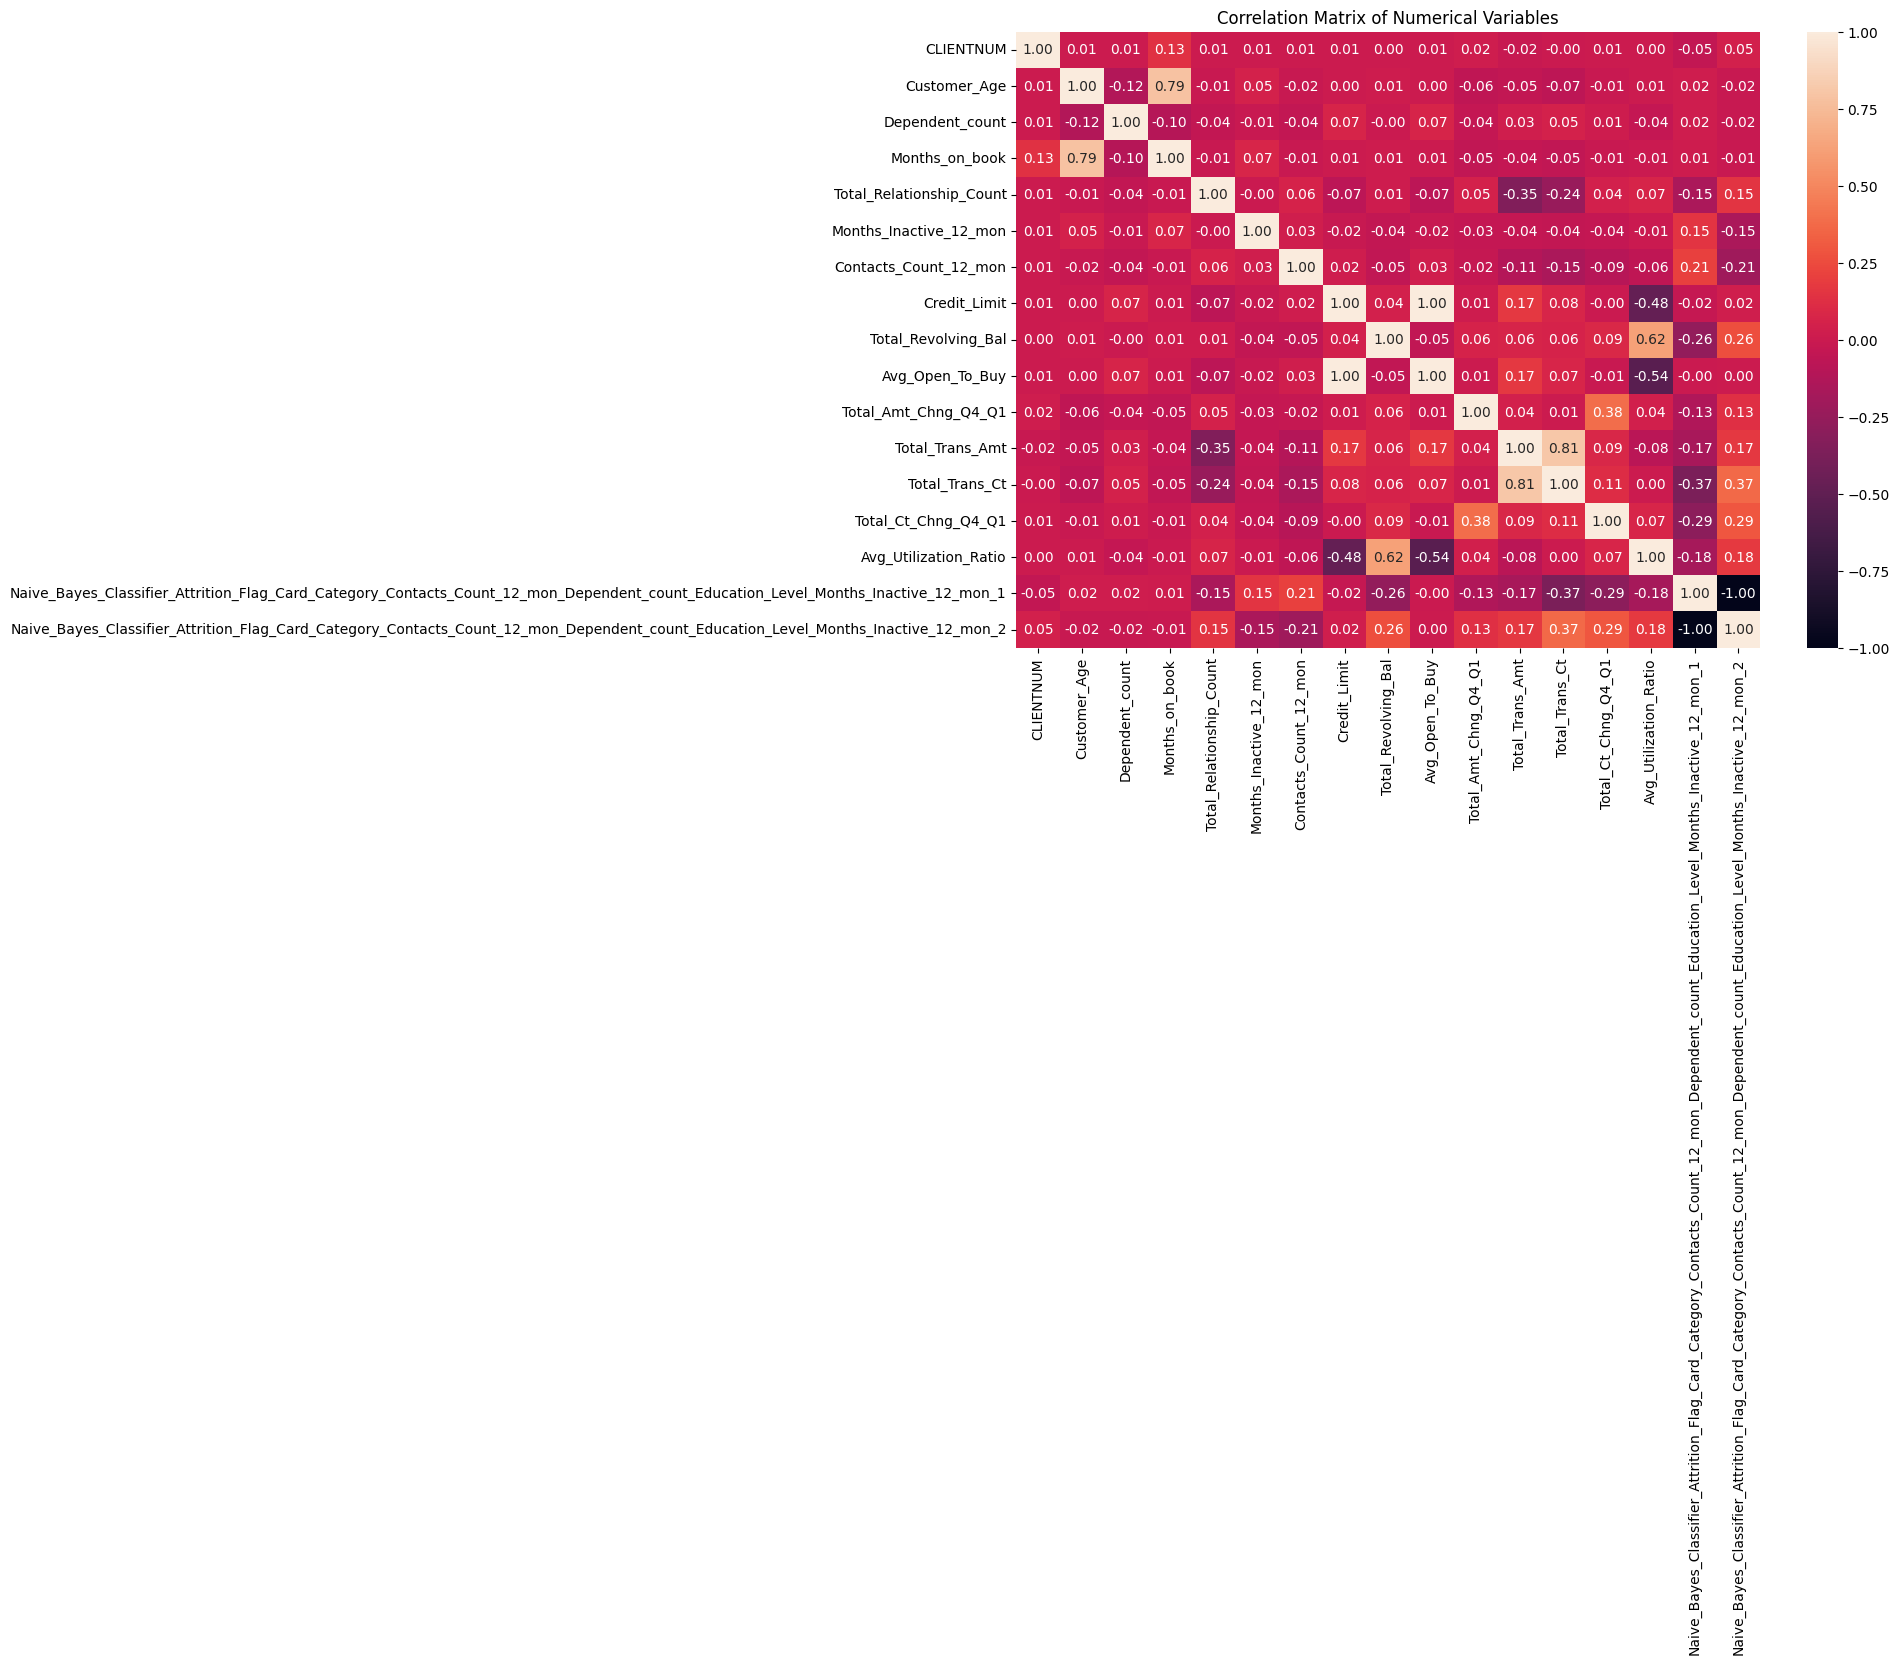

In [ ]:

plt.figure(figsize=(12, 8))

numeric_df = df.select_dtypes(include='number')

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    fmt='.2f'
)

plt.title('Correlation Matrix of Numerical Variables')

plt.show()

EDA - Correlation Matrix

This is to identify relationships between numerical variables.

In [ ]:

df_clean = df.drop(
    columns=[
        'CLIENTNUM',
        'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1',
        'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2'
    ]
)

In [ ]:
df_clean.shape

(10127, 20)

In [ ]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Attrition_Flag            10127 non-null  object 
 1   Customer_Age              10127 non-null  int64  
 2   Gender                    10127 non-null  object 
 3   Dependent_count           10127 non-null  int64  
 4   Education_Level           10127 non-null  object 
 5   Marital_Status            10127 non-null  object 
 6   Income_Category           10127 non-null  object 
 7   Card_Category             10127 non-null  object 
 8   Months_on_book            10127 non-null  int64  
 9   Total_Relationship_Count  10127 non-null  int64  
 10  Months_Inactive_12_mon    10127 non-null  int64  
 11  Contacts_Count_12_mon     10127 non-null  int64  
 12  Credit_Limit              10127 non-null  float64
 13  Total_Revolving_Bal       10127 non-null  int64  
 14  Avg_Op

In [ ]:
df_clean.isnull().sum()

,0
Attrition_Flag,0
Customer_Age,0
Gender,0
Dependent_count,0
Education_Level,0
Marital_Status,0
Income_Category,0
Card_Category,0
Months_on_book,0
Total_Relationship_Count,0


In [ ]:
df_clean.duplicated().sum()

np.int64(0)

 Data Cleaning and Justification

The dataset was reviewed for missing values, duplicate records, irrelevant variables, and variables that could introduce data leakage.

"CLIENTNUM" was removed because it is a customer identification number and does not provide meaningful information for understanding customer behaviour or attrition.

The two Naive Bayes classifier columns were also removed because they contain model-generated information related to the attrition outcome. Keeping these variables in the analysis could introduce data leakage and produce misleading relationships with the target variable.

No missing values were identified, so no imputation was necessary. Duplicate records were also checked and treated according to the results of the duplicate assessment.

The remaining variables were retained because they contain customer demographic, account, and transaction information that can be meaningfully examined in relation to customer attrition.